# Week 2 — Solving Systems of Linear Equations

## Task 3 — Gauss-Jordan method

$$
\begin{cases}
2x_1 + 2x_2 - x_3 + x_5 = 0 \\
-x_1 - x_2 + 2x_3 - 3x_4 + x_5 = 0 \\
x_1 + x_2 - 2x_3 - x_5 = 0 \\
x_3 + x_4 + x_5 = 0
\end{cases}
$$

4 equations, 5 unknowns → the system is underdetermined (rank 3), so we express the solution in terms of one free variable.

In [1]:
import numpy as np


def gauss_jordan(A, b, verbose=True):
    aug = np.hstack([A, b.reshape(-1, 1)]).astype(float)
    rows, cols = aug.shape
    n_vars = cols - 1
    pivot_cols = []
    row = 0
    for col in range(n_vars):
        pivot, max_val = None, 1e-9
        for r in range(row, rows):
            if abs(aug[r, col]) > max_val:
                pivot, max_val = r, abs(aug[r, col])
        if pivot is None:
            continue
        aug[[row, pivot]] = aug[[pivot, row]]
        aug[row] /= aug[row, col]
        for r in range(rows):
            if r != row:
                aug[r] -= aug[r, col] * aug[row]
        pivot_cols.append(col)
        if verbose:
            print(f"Pivot on x{col + 1}:\n{np.round(aug, 4)}\n")
        row += 1
        if row == rows:
            break
    return aug, pivot_cols


A = np.array([
    [2, 2, -1, 0, 1],
    [-1, -1, 2, -3, 1],
    [1, 1, -2, 0, -1],
    [0, 0, 1, 1, 1],
])
b = np.zeros(4)

rref, pivot_cols = gauss_jordan(A, b)

n_vars = A.shape[1]
free_cols = [c for c in range(n_vars) if c not in pivot_cols]
print("Reduced row echelon form:\n", np.round(rref, 4))
print("\nPivot variables:", [f"x{c+1}" for c in pivot_cols])
print("Free variables:  ", [f"x{c+1}" for c in free_cols])
for r, c in enumerate(pivot_cols):
    terms = " ".join(f"- {rref[r, fc]:+.0f}*x{fc+1}" for fc in free_cols if rref[r, fc] != 0)
    print(f"x{c+1} = {rref[r, -1]:.0f} {terms}")


Pivot on x1:
[[ 1.   1.  -0.5  0.   0.5  0. ]
 [ 0.   0.   1.5 -3.   1.5  0. ]
 [ 0.   0.  -1.5  0.  -1.5  0. ]
 [ 0.   0.   1.   1.   1.   0. ]]

Pivot on x3:
[[ 1.  1.  0. -1.  1.  0.]
 [ 0.  0.  1. -2.  1.  0.]
 [ 0.  0.  0. -3.  0.  0.]
 [ 0.  0.  0.  3.  0.  0.]]

Pivot on x4:
[[ 1.  1.  0.  0.  1.  0.]
 [ 0.  0.  1.  0.  1.  0.]
 [-0. -0. -0.  1. -0. -0.]
 [ 0.  0.  0.  0.  0.  0.]]

Reduced row echelon form:
 [[ 1.  1.  0.  0.  1.  0.]
 [ 0.  0.  1.  0.  1.  0.]
 [-0. -0. -0.  1. -0. -0.]
 [ 0.  0.  0.  0.  0.  0.]]

Pivot variables: ['x1', 'x3', 'x4']
Free variables:   ['x2', 'x5']
x1 = 0 - +1*x2 - +1*x5
x3 = 0 - +1*x5
x4 = -0 


## Task 5 — Gauss-Seidel method

$$
\begin{cases}
4x + y + z = 7 \\
x + 5y + 2z = 10 \\
x + 2y + 6z = 14
\end{cases}
$$

3 iterations starting from $(0, 0, 0)$, compared against the Jacobi result from Task 4.

In [ ]:
def is_diagonally_dominant(A):
    """Strict row-wise diagonal dominance: |a_ii| > sum of other |a_ij| in that row.
    Sufficient (not necessary) condition for Gauss-Seidel to converge."""
    diag = np.abs(np.diag(A))
    off_diag_sum = np.sum(np.abs(A), axis=1) - diag
    return bool(np.all(diag > off_diag_sum))


def gauss_seidel(A, b, x0, max_iter):
    if not is_diagonally_dominant(A):
        print("Warning: A is not strictly diagonally dominant — convergence is not guaranteed.\n")

    x = np.array(x0, dtype=float)
    n = len(b)
    rows = []

    for k in range(1, max_iter + 1):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i, j] * x_new[j] for j in range(i))
            s2 = sum(A[i, j] * x[j] for j in range(i + 1, n))
            x_new[i] = (b[i] - s1 - s2) / A[i, i]
        err = np.max(np.abs(x_new - x))
        rows.append((k, *x_new, err))
        x = x_new

    return x, rows


def print_gauss_seidel_table(rows):
    print(f"\n{'k':>3} {'x1':>12} {'x2':>12} {'x3':>12} {'err':>12}")
    for k, x1, x2, x3, err in rows:
        print(f"{k:>3} {x1:>12.6f} {x2:>12.6f} {x3:>12.6f} {err:>12.6e}")


A = np.array([
    [4, 1, 1],
    [1, 5, 2],
    [1, 2, 6],
])
b = np.array([7, 10, 14])
x0 = [0, 0, 0]

print(f"Diagonally dominant: {is_diagonally_dominant(A)}")
for i in range(A.shape[0]):
    diag = abs(A[i, i])
    off = sum(abs(A[i, j]) for j in range(A.shape[1]) if j != i)
    print(f"  row {i + 1}: |a_{i+1}{i+1}| = {diag} {'>' if diag > off else '<='} sum of others = {off}")

x, rows = gauss_seidel(A, b, x0, max_iter=3)
print_gauss_seidel_table(rows)
print(f"\nApproximate solution after 3 iterations: {np.round(x, 4)}")


## Method Comparison

Run Gauss-Jordan (direct, one-shot) and Gauss-Seidel (iterative) on the same 3×3 system from Task 5, and compare: exact solution reached, convergence speed (error vs. exact per iteration), and runtime.

  k           x1           x2           x3   error vs exact
  1     1.750000     1.650000     1.491667     7.190722e-01
  2     0.964583     1.210417     1.769097     1.382517e-01
  3     1.005122     1.091337     1.802034     2.580631e-02
  4     1.026657     1.073855     1.804272     4.270572e-03
  5     1.030468     1.072197     1.804189     4.595974e-04
  6     1.030903     1.072144     1.804135     2.457326e-05
  7     1.030930     1.072160     1.804125     4.997854e-06
  8     1.030929     1.072164     1.804124     9.388310e-07
  9     1.030928     1.072165     1.804124     1.532477e-07
 10     1.030928     1.072165     1.804124     1.627941e-08

Gauss-Jordan exact solution: [1.030928 1.072165 1.804124]
Gauss-Jordan runtime:  0.000219 s (1 pass, exact)
Gauss-Seidel runtime:  0.000119 s (10 iterations)
Gauss-Seidel iterations to reach 1e-6 error: 8


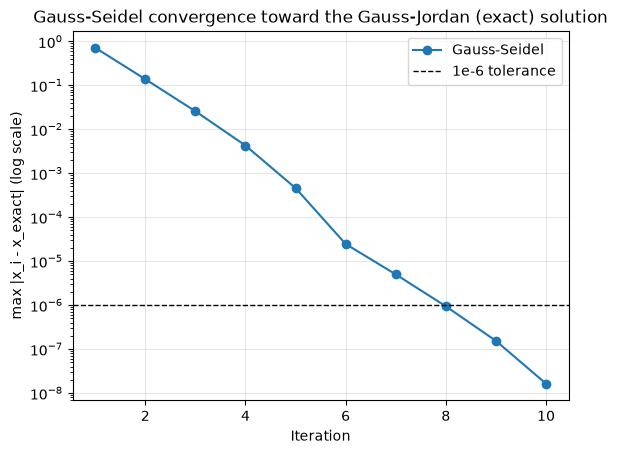

In [3]:
import time
import matplotlib.pyplot as plt

MAX_ITER = 10

# Gauss-Jordan: direct solution + timing
t0 = time.perf_counter()
gj_rref, _ = gauss_jordan(A, b, verbose=False)
gj_time = time.perf_counter() - t0
exact = gj_rref[:, -1]

# Gauss-Seidel: iterate further and track error against the Gauss-Jordan solution
t0 = time.perf_counter()
_, gs_rows = gauss_seidel(A, b, x0, max_iter=MAX_ITER)
gs_time = time.perf_counter() - t0

print(f"{'k':>3} {'x1':>12} {'x2':>12} {'x3':>12} {'error vs exact':>16}")
gs_errors = []
for k, x1, x2, x3, step_err in gs_rows:
    err_exact = np.max(np.abs(np.array([x1, x2, x3]) - exact))
    gs_errors.append(err_exact)
    print(f"{k:>3} {x1:>12.6f} {x2:>12.6f} {x3:>12.6f} {err_exact:>16.6e}")

print(f"\nGauss-Jordan exact solution: {np.round(exact, 6)}")
print(f"Gauss-Jordan runtime:  {gj_time:.6f} s (1 pass, exact)")
print(f"Gauss-Seidel runtime:  {gs_time:.6f} s ({MAX_ITER} iterations)")
print(f"Gauss-Seidel iterations to reach 1e-6 error: "
      f"{next((k for k, e in enumerate(gs_errors, 1) if e < 1e-6), '> ' + str(MAX_ITER))}")

plt.figure()
plt.semilogy(range(1, MAX_ITER + 1), gs_errors, marker="o", label="Gauss-Seidel")
plt.axhline(1e-6, color="black", linewidth=1, linestyle="--", label="1e-6 tolerance")
plt.title("Gauss-Seidel convergence toward the Gauss-Jordan (exact) solution")
plt.xlabel("Iteration")
plt.ylabel("max |x_i - x_exact| (log scale)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("gauss_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
